MODELO PRINCIPAL PARA OPTIMIZACION

In [1]:
import pandas as pd

df = pd.read_excel("Base_de_datos_CA.xlsx")

df.head()

,ID_PISCINA,TAN,NH3T,NO2,NO3,PO4,SULFURO,ALK,PH,TEMP,SALINIDAD,R_NP,N_ENF,NRS
0,CA_001,0.08,0.000,0.043,1.577,0.25,0.05,145.0,6.84,26.9,33.0,5.299515,3.0,MEDIO
1,CA_002,0.02,0.001,0.036,2.104,0.96,0.03,165.0,7.80,28.0,30.0,1.610227,3.0,MEDIO
2,CA_003,0.05,0.000,0.700,1.750,0.84,0.03,130.0,7.06,27.8,30.0,2.348485,3.0,ALTO
3,CA_004,0.17,0.009,0.066,0.957,0.36,0.07,360.0,8.10,21.6,6.0,3.121296,3.0,MEDIO
4,CA_005,0.27,0.011,0.046,0.930,0.28,0.05,320.0,7.67,21.5,6.0,4.714286,3.0,MEDIO


In [2]:
# Variable objetivo
y = df["NRS"]

# Variables de entrada
X = df.drop(columns=["ID_PISCINA", "NRS", "N_ENF"])

In [3]:
print(X.isnull().sum())
print(df["NRS"].value_counts())

TAN           0
NH3T          0
NO2           0
NO3           1
PO4           0
SULFURO      63
ALK          10
PH            0
TEMP          0
SALINIDAD     0
R_NP          0
dtype: int64
NRS
BAJO     59
MEDIO    54
ALTO     40
Name: count, dtype: int64


In [4]:
# Rellenar valores faltantes con la media
X["SULFURO"].fillna(X["SULFURO"].mean(), inplace=True)
X["ALK"].fillna(X["ALK"].mean(), inplace=True)
X["NO3"].fillna(X["NO3"].mean(), inplace=True)

/tmp/ipykernel_17492/545327332.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X["SULFURO"].fillna(X["SULFURO"].mean(), inplace=True)
/tmp/ipykernel_17492/545327332.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (122, 11)
Test: (31, 11)


In [6]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [7]:
y_pred = modelo_rf.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8387096774193549

Classification Report:

              precision    recall  f1-score   support

        ALTO       0.88      0.88      0.88         8
        BAJO       1.00      0.75      0.86        12
       MEDIO       0.71      0.91      0.80        11

    accuracy                           0.84        31
   macro avg       0.86      0.84      0.84        31
weighted avg       0.87      0.84      0.84        31


Confusion Matrix:

[[ 7  0  1]
 [ 0  9  3]
 [ 1  0 10]]


OPTIMIZACION DEL MODELO

1. Baseline del modelo actual

In [9]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

y_pred_base = modelo_rf.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average="macro")

print("=== MODELO BASE RANDOM FOREST ===")
print("Accuracy base:", acc_base)
print("F1 macro base:", f1_base)
print(classification_report(y_test, y_pred_base))

=== MODELO BASE RANDOM FOREST ===
Accuracy base: 0.8387096774193549
F1 macro base: 0.8440476190476192
              precision    recall  f1-score   support

        ALTO       0.88      0.88      0.88         8
        BAJO       1.00      0.75      0.86        12
       MEDIO       0.71      0.91      0.80        11

    accuracy                           0.84        31
   macro avg       0.86      0.84      0.84        31
weighted avg       0.87      0.84      0.84        31



2. GridSearch para optimización

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid.best_params_)

print("Mejor F1 macro en validación cruzada:")
print(grid.best_score_)

Mejores parámetros encontrados:
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1 macro en validación cruzada:
0.7038040608628844


3. Evaluación del modelo optimizado

In [11]:
modelo_opt = grid.best_estimator_

y_pred_opt = modelo_opt.predict(X_test)

acc_opt = accuracy_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt, average="macro")

print("=== MODELO OPTIMIZADO ===")
print("Accuracy optimizado:", acc_opt)
print("F1 macro optimizado:", f1_opt)
print("Mejora en accuracy:", acc_opt - acc_base)
print("Mejora en F1 macro:", f1_opt - f1_base)

print(classification_report(y_test, y_pred_opt))

=== MODELO OPTIMIZADO ===
Accuracy optimizado: 0.8064516129032258
F1 macro optimizado: 0.8007246376811593
Mejora en accuracy: -0.032258064516129115
Mejora en F1 macro: -0.043322981366459845
              precision    recall  f1-score   support

        ALTO       0.75      0.75      0.75         8
        BAJO       0.91      0.83      0.87        12
       MEDIO       0.75      0.82      0.78        11

    accuracy                           0.81        31
   macro avg       0.80      0.80      0.80        31
weighted avg       0.81      0.81      0.81        31



4. Tabla comparativa base vs optimizado

In [12]:
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Random Forest Base", "Random Forest Optimizado"],
    "Accuracy": [acc_base, acc_opt],
    "F1_macro": [f1_base, f1_opt]
})

print(comparacion_modelos)

                     Modelo  Accuracy  F1_macro
0        Random Forest Base  0.838710  0.844048
1  Random Forest Optimizado  0.806452  0.800725


5. Ranking de combinaciones de hiperparámetros

In [13]:
resultados_grid = pd.DataFrame(grid.cv_results_)

ranking_hiperparametros = resultados_grid[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values(by="rank_test_score")

print(ranking_hiperparametros.head(10))

                                               params  mean_test_score  \
10  {'class_weight': 'balanced', 'max_depth': None...         0.703804   
64  {'class_weight': 'balanced', 'max_depth': 10, ...         0.703804   
55  {'class_weight': 'balanced', 'max_depth': 10, ...         0.699290   
1   {'class_weight': 'balanced', 'max_depth': None...         0.699290   
33  {'class_weight': 'balanced', 'max_depth': 5, '...         0.697630   
32  {'class_weight': 'balanced', 'max_depth': 5, '...         0.696248   
41  {'class_weight': 'balanced', 'max_depth': 5, '...         0.696248   
34  {'class_weight': 'balanced', 'max_depth': 5, '...         0.693507   
43  {'class_weight': 'balanced', 'max_depth': 5, '...         0.691494   
24  {'class_weight': 'balanced', 'max_depth': None...         0.688598   

    std_test_score  rank_test_score  
10        0.117182                1  
64        0.117182                1  
55        0.125107                3  
1         0.125107               

6. Importancia de variables del modelo optimizado

In [14]:
importancias_opt = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_opt.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print(importancias_opt)

     Variable  Importancia
4         PO4     0.161634
0         TAN     0.146156
1        NH3T     0.126791
8        TEMP     0.097989
6         ALK     0.097424
10       R_NP     0.089924
3         NO3     0.069879
7          PH     0.065407
2         NO2     0.063745
9   SALINIDAD     0.058497
5     SULFURO     0.022554


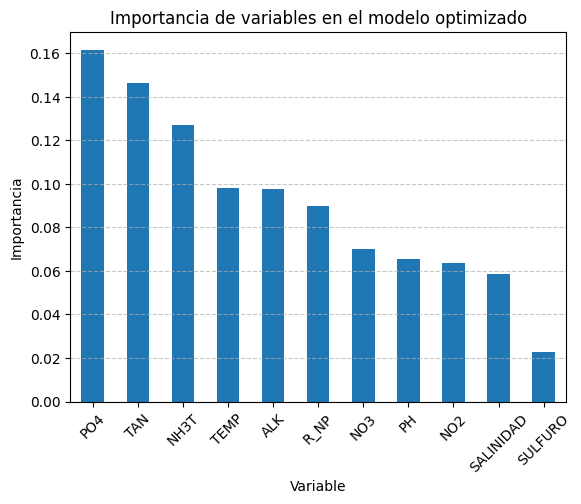

In [15]:
import matplotlib.pyplot as plt

ax = importancias_opt.plot(
    x="Variable",
    y="Importancia",
    kind="bar",
    legend=False
)

plt.title("Importancia de variables en el modelo optimizado")
plt.ylabel("Importancia")
plt.xlabel("Variable")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

7. Partial Dependence Plots

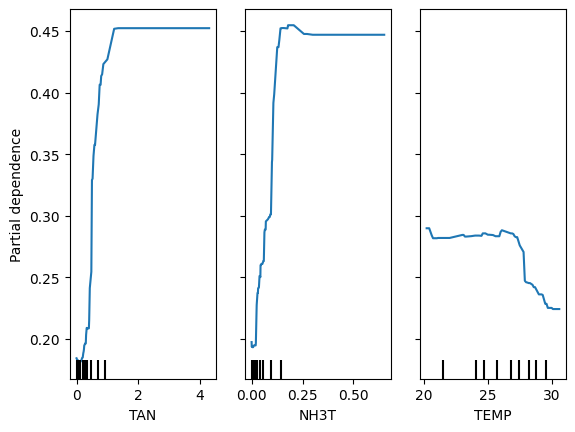

In [17]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features = ["TAN", "NH3T", "TEMP"]

PartialDependenceDisplay.from_estimator(
    modelo_opt,
    X_train,
    features,
    target="ALTO"
)

plt.show()

8. Efecto de interacción entre variables

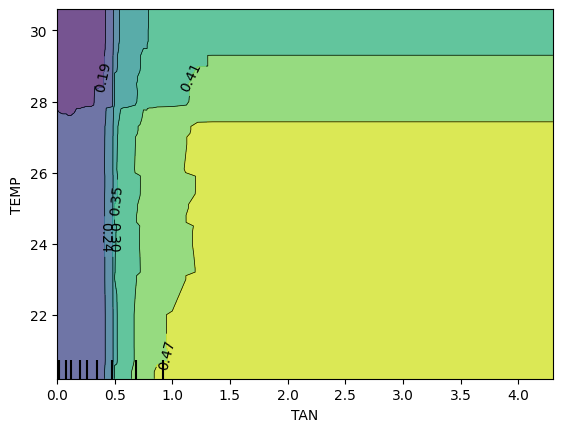

In [20]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(
    modelo_opt,
    X_train,
    [("TAN", "TEMP")],
    target="ALTO"
)

plt.show()

9. Validación rápida en escenario crítico con modelo optimizado

In [21]:
X_drift_opt = X_test.copy()
X_drift_opt["TEMP"] = X_drift_opt["TEMP"] + 3
X_drift_opt["SALINIDAD"] = X_drift_opt["SALINIDAD"] - 5
X_drift_opt["TAN"] = X_drift_opt["TAN"] * 1.3

y_pred_drift_opt = modelo_opt.predict(X_drift_opt)

acc_drift_opt = accuracy_score(y_test, y_pred_drift_opt)
f1_drift_opt = f1_score(y_test, y_pred_drift_opt, average="macro")

print("=== MODELO OPTIMIZADO BAJO DATA DRIFT ===")
print("Accuracy drift optimizado:", acc_drift_opt)
print("F1 macro drift optimizado:", f1_drift_opt)
print(classification_report(y_test, y_pred_drift_opt))

=== MODELO OPTIMIZADO BAJO DATA DRIFT ===
Accuracy drift optimizado: 0.7419354838709677
F1 macro drift optimizado: 0.747500581260172
              precision    recall  f1-score   support

        ALTO       0.78      0.88      0.82         8
        BAJO       0.82      0.75      0.78        12
       MEDIO       0.64      0.64      0.64        11

    accuracy                           0.74        31
   macro avg       0.74      0.75      0.75        31
weighted avg       0.74      0.74      0.74        31

